In [17]:
import os
import struct
import numpy as np
import matplotlib.pyplot as plt

archive = "../../../resources/archive/"
train_images_file = os.path.join(archive, "train-images.idx3-ubyte")
train_labels_file = os.path.join(archive, "train-labels.idx1-ubyte")
test_images_file = os.path.join(archive, "t10k-images.idx3-ubyte")
test_labels_file = os.path.join(archive, "t10k-labels.idx1-ubyte")

def read_images(file_path):
  with open(file_path, "rb") as f:
    magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
    images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num_images, rows, cols)
  return images.reshape(num_images, rows*cols)

def read_labels(file_path):
  with open(file_path, "rb") as f:
    magic, num_labels = struct.unpack(">II", f.read(8))
    labels = np.frombuffer(f.read(), dtype=np.uint8)
  return labels

train_images = read_images(train_images_file)
train_labels = read_labels(train_labels_file)
test_images = read_images(test_images_file)
test_labels = read_labels(test_labels_file)

print(f"Training set: {train_images.shape[0]} images, each of size {train_images.shape[1]}")
print(f"Test set: {test_images.shape[0]} images, each of size {test_images.shape[1]}")


Training set: 60000 images, each of size 784
Test set: 10000 images, each of size 784


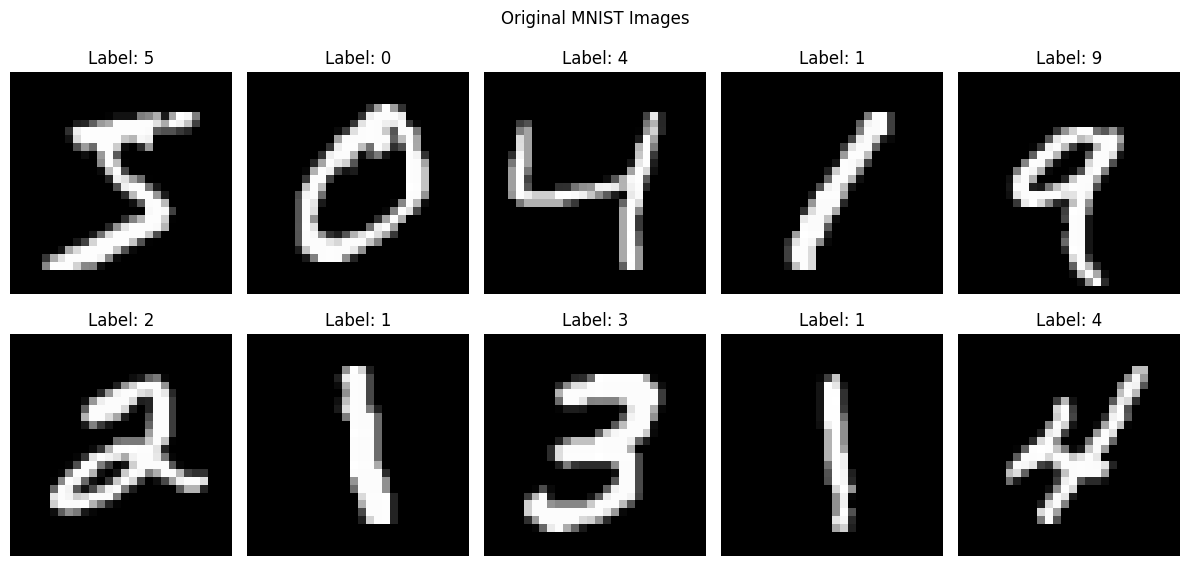

In [18]:
def visualize_images(images, labels, num_images=10, title="Images"):
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    fig.suptitle(title)
    
    for i in range(num_images):
        row, col = i // 5, i % 5
        axes[row, col].imshow(images[i].reshape(28, 28), cmap='gray')
        axes[row, col].set_title(f'Label: {labels[i]}')
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_images(train_images, train_labels, title="Original MNIST Images")

In [ ]:
from scipy.ndimage import rotate, shift, zoom
import matplotlib.pyplot as plt

def apply_random_transforms(images, labels):
    transformed_images = []
    transformed_labels = []
    
    for img, label in zip(images, labels):
        img_2d = img.reshape(28, 28).astype(np.float32)
        
        # Random rotation
        angle = np.random.uniform(-90, 90)
        img_2d = rotate(img_2d, angle, reshape=False, cval=0)
        
        # Random offset
        shift_x = np.random.uniform(-7, 7)
        shift_y = np.random.uniform(-7, 7)
        img_2d = shift(img_2d, [shift_y, shift_x], cval=0)
        
        # Random scale
        scale = np.random.uniform(0.7, 1.3)
        if scale != 1.0:
            img_2d = zoom(img_2d, scale, order=1)
            # Ensure 28x28 shape
            if img_2d.shape[0] != 28 or img_2d.shape[1] != 28:
                # Crop or pad to 28x28
                h, w = img_2d.shape
                if h > 28:
                    start_h = (h - 28) // 2
                    img_2d = img_2d[start_h:start_h+28, :]
                if w > 28:
                    start_w = (w - 28) // 2
                    img_2d = img_2d[:, start_w:start_w+28]
                if h < 28 or w < 28:
                    pad_h = max(0, (28 - h) // 2)
                    pad_w = max(0, (28 - w) // 2)
                    img_2d = np.pad(img_2d, ((pad_h, 28-h-pad_h), (pad_w, 28-w-pad_w)), mode='constant')
        
        # Random noise
        noise = np.random.normal(-231, 24, (28, 28))
        noise2 = np.random.normal(231, 24, (28, 28))
        img_2d = np.clip(img_2d + noise+noise2, 0, 255)
        
        transformed_images.append(img_2d.flatten())
        transformed_labels.append(label)
    
    return np.array(transformed_images, dtype=np.uint8), np.array(transformed_labels)

train_images_aug, train_labels_aug = apply_random_transforms(train_images[:100], train_labels[:100])


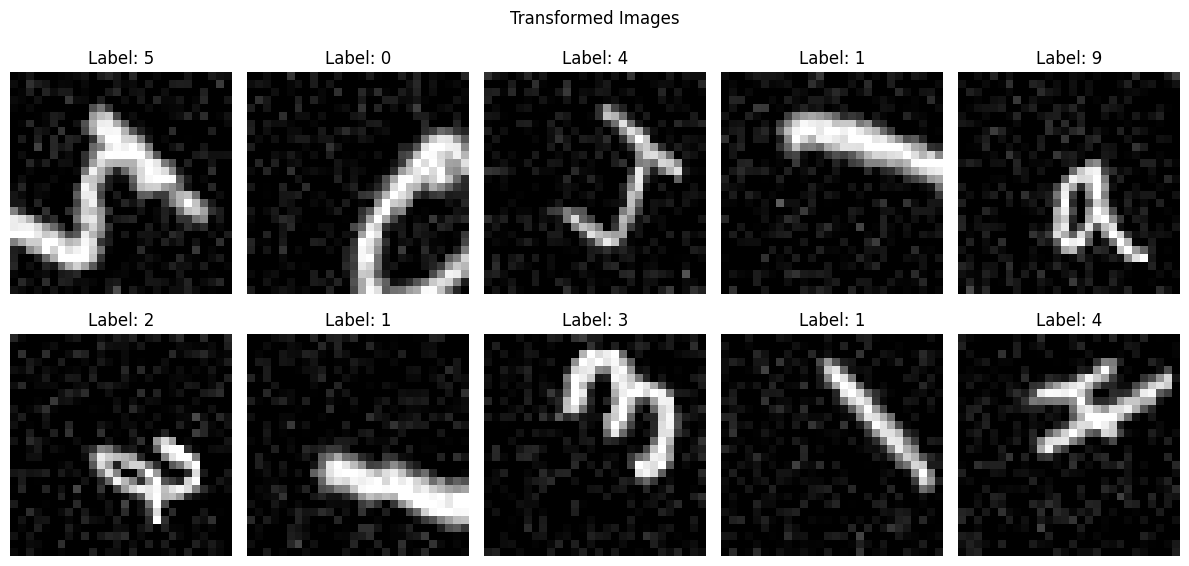

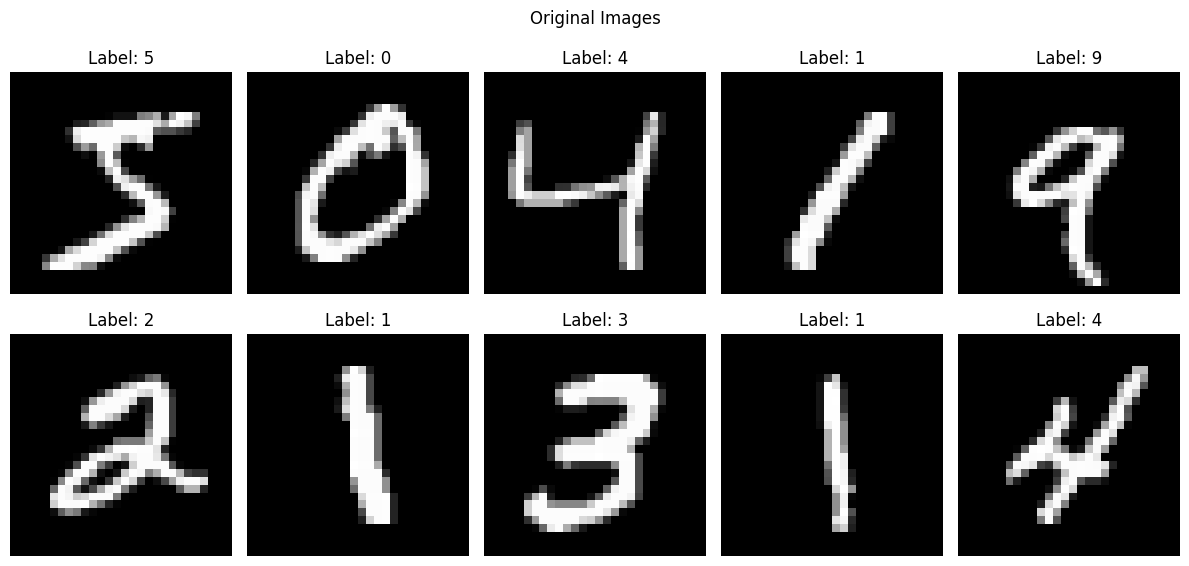

In [53]:
visualize_images(train_images_aug, train_labels_aug, title="Transformed Images")
visualize_images(train_images, train_labels, title="Original Images")